# 01 — Data Audit and EDA (Data Gate)

**Project:** Student Performance Early-Warning Model (EDU-02, OULAD)
**Purpose:** produce the Data Gate evidence — audit the data *before* any modeling,
following the course framework: **Structure → Quality → Distribution → Meaning → Order**,
plus checks specific to our early-warning prediction point.

Written conclusions and the issue log live in [`docs/data_audit.md`](../docs/data_audit.md).
Every conclusion there points back to an output in this notebook.

**Before running:** download the data first (`python src/download_data.py`, see
[`data/README.md`](../data/README.md)). Figures are saved to `reports/figures/`.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Resolve the repo root so the notebook works both locally and in Colab
# (in Colab: clone the repo and cd into it first).
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

courses = pd.read_csv(RAW / "courses.csv")
assessments = pd.read_csv(RAW / "assessments.csv")
vle = pd.read_csv(RAW / "vle.csv")
student_info = pd.read_csv(RAW / "studentInfo.csv")
registration = pd.read_csv(RAW / "studentRegistration.csv")
student_assessment = pd.read_csv(RAW / "studentAssessment.csv")
# studentVle has 10.6M rows -> smaller dtypes keep memory low
student_vle = pd.read_csv(RAW / "studentVle.csv",
                          dtype={"id_student": "int32", "id_site": "int32",
                                 "date": "int16", "sum_click": "int16"})

KEY = ["code_module", "code_presentation", "id_student"]
tables = {"courses": courses, "assessments": assessments, "vle": vle,
          "studentInfo": student_info, "studentRegistration": registration,
          "studentAssessment": student_assessment, "studentVle": student_vle}
for name, df in tables.items():
    print(f"{name:20s} {df.shape}")

courses              (22, 3)
assessments          (206, 6)
vle                  (6364, 6)
studentInfo          (32593, 12)
studentRegistration  (32593, 5)
studentAssessment    (173912, 5)
studentVle           (10655280, 6)


## A. Structure — what one row means

The unit of analysis is **one student in one module-presentation** (`studentInfo` row,
key = `code_module` + `code_presentation` + `id_student`). A presentation is one run of
a course: `B` = February start, `J` = October start. All dates in the dataset are
**days relative to the presentation start** (day 0 = course start).

In [2]:
print("Presentation length (days) per module-presentation:")
print(courses.pivot_table(index="code_module", columns="code_presentation",
                          values="module_presentation_length"))
print("\nstudentInfo dtypes:")
print(student_info.dtypes)
print("\nassessment types:", assessments.assessment_type.value_counts().to_dict())
print("VLE activity types:", vle.activity_type.nunique(), "distinct")
print("studentVle date range:", student_vle.date.min(), "to", student_vle.date.max())

Presentation length (days) per module-presentation:
code_presentation  2013B  2013J  2014B  2014J
code_module                                  
AAA                  NaN  268.0    NaN  269.0
BBB                240.0  268.0  234.0  262.0
CCC                  NaN    NaN  241.0  269.0
DDD                240.0  261.0  241.0  262.0
EEE                  NaN  268.0  241.0  269.0
FFF                240.0  268.0  241.0  269.0
GGG                  NaN  261.0  241.0  269.0

studentInfo dtypes:
code_module               str
code_presentation         str
id_student              int64
gender                    str
region                    str
highest_education         str
imd_band                  str
age_band                  str
num_of_prev_attempts    int64
studied_credits         int64
disability               bool
final_result              str
dtype: object

assessment types: {'TMA': 106, 'CMA': 76, 'Exam': 24}
VLE activity types: 20 distinct
studentVle date range: -25 to 269


**Conclusion (Structure):** 7 modules × 4 possible presentations = 22
module-presentations, 234–269 days long. *Not every module runs every presentation*:
CCC exists only in 2014B/2014J and AAA only in 2013J/2014J — this matters for our
train-on-earlier / test-on-later split (see section E). Keys are clean; dates are
relative day numbers, which makes an "early window" easy to define consistently.

## B. Quality — missingness, duplicates, invalid values

In [3]:
print("Duplicates on the student-presentation key:")
print("  studentInfo:", student_info.duplicated(KEY).sum())
print("  studentRegistration:", registration.duplicated(KEY).sum())
print("  studentAssessment (id_assessment,id_student):",
      student_assessment.duplicated(["id_assessment", "id_student"]).sum())

print("\nMissing values:")
print("  studentInfo:", student_info.isna().sum()[lambda s: s > 0].to_dict())
print("  registration: date_registration:", registration.date_registration.isna().sum(),
      "| date_unregistration:", registration.date_unregistration.isna().sum(),
      "(missing = student never withdrew - expected)")
print("  studentAssessment score:", student_assessment.score.isna().sum())
no_date = assessments[assessments.date.isna()]
print("  assessments with no due date:", len(no_date),
      "- all type:", no_date.assessment_type.unique())

print("\nimd_band category labels (note the inconsistent '10-20'):")
print(sorted(student_info.imd_band.dropna().unique()))

Duplicates on the student-presentation key:
  studentInfo: 0
  studentRegistration: 0
  studentAssessment (id_assessment,id_student): 0

Missing values:
  studentInfo: {'imd_band': 1111}
  registration: date_registration: 45 | date_unregistration: 22521 (missing = student never withdrew - expected)
  studentAssessment score: 173
  assessments with no due date: 11 - all type: <StringArray>
['Exam']
Length: 1, dtype: str

imd_band category labels (note the inconsistent '10-20'):
['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']


**Conclusion (Quality):** No duplicate keys anywhere — each student appears
once per module-presentation. Missingness is small and explainable:
`imd_band` missing for 1,111 rows (3.4%) — we will treat "missing" as its own category
because it is likely informative (see section D); 45 missing registration dates; 173
missing assessment scores (unsubmitted); the 11 assessments without a due date are all
final **Exams**, which we exclude anyway (after the prediction point). One real defect:
the `imd_band` label `10-20` is missing its `%` suffix — cosmetic, fixed in preprocessing.
All findings are recorded in the issue log (`docs/issue_log.csv`).

## C. Distribution — target balance and activity skew

Target: **at risk = Withdrawn or Fail** vs **not at risk = Pass or Distinction**.

final_result counts:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

Overall at-risk rate (before population filtering): 52.8%


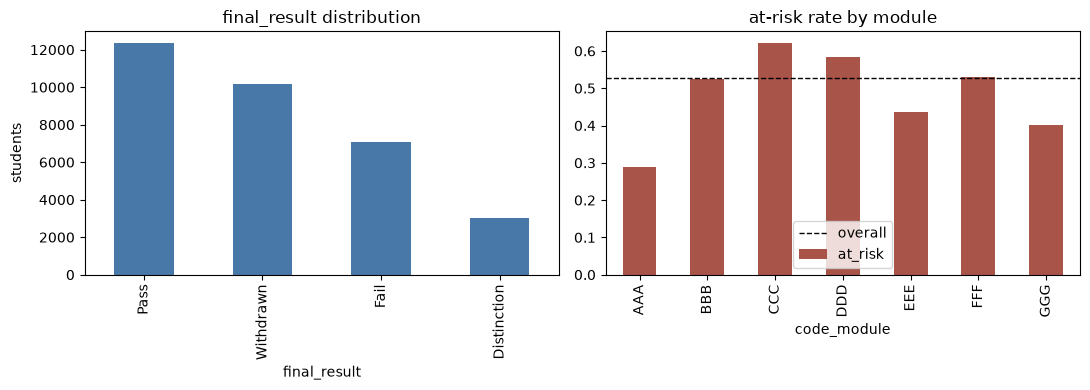


at-risk rate by presentation:
                   count   mean
code_presentation              
2013B               4684  0.553
2013J               8845  0.494
2014B               7804  0.570
2014J              11260  0.515


In [4]:
student_info["at_risk"] = student_info.final_result.isin(["Withdrawn", "Fail"]).astype(int)

print("final_result counts:")
print(student_info.final_result.value_counts())
print(f"\nOverall at-risk rate (before population filtering): {student_info.at_risk.mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
student_info.final_result.value_counts().plot.bar(ax=axes[0], color="#4878a8")
axes[0].set_title("final_result distribution")
axes[0].set_ylabel("students")
student_info.groupby("code_module").at_risk.mean().plot.bar(ax=axes[1], color="#a85448")
axes[1].axhline(student_info.at_risk.mean(), ls="--", c="k", lw=1, label="overall")
axes[1].set_title("at-risk rate by module")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG / "target_balance.png", dpi=120)
plt.show()

print("\nat-risk rate by presentation:")
print(student_info.groupby("code_presentation").at_risk.agg(["count", "mean"]).round(3))

**Conclusion (Distribution):** The binary target is moderately balanced
overall (~53% at risk before population filtering, ~41% after — see section F), so this
is not an extreme-imbalance problem, but the rate swings a lot by module (AAA 29% →
CCC 62%). Accuracy alone would still be misleading across modules; Recall/F1 on the
at-risk class (per the approved brief) remain the right metrics, and per-module results
must be reported at evaluation time.

## D. Meaning — target validity and fairness base rates

The target derives from `final_result` only — it is what we want to predict, and no
feature may be derived from it. Sensitive attributes exist in the data, so we check
base rates now (before modeling) to know where the model could encode disadvantage.

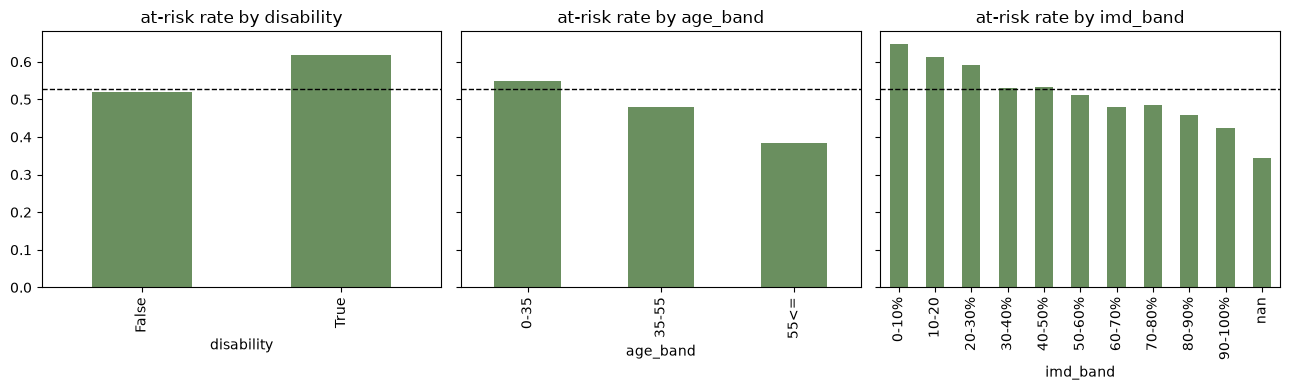

            count   mean
disability              
False       29429  0.518
True         3164  0.619 

        count   mean
gender              
F       14718  0.516
M       17875  0.538 

          count   mean
age_band              
0-35      22944  0.550
35-55      9433  0.478
55<=        216  0.384 

          count   mean
imd_band              
0-10%      3311  0.648
10-20      3516  0.614
20-30%     3654  0.593
30-40%     3539  0.531
40-50%     3256  0.534
50-60%     3124  0.512
60-70%     2905  0.481
70-80%     2879  0.485
80-90%     2762  0.459
90-100%    2536  0.425
NaN        1111  0.343 



In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, col in zip(axes, ["disability", "age_band", "imd_band"]):
    rates = student_info.groupby(col, dropna=False).at_risk.mean()
    if col == "imd_band":
        rates = rates.sort_index(na_position="last")
    rates.plot.bar(ax=ax, color="#6a8f5f")
    ax.axhline(student_info.at_risk.mean(), ls="--", c="k", lw=1)
    ax.set_title(f"at-risk rate by {col}")
plt.tight_layout()
plt.savefig(FIG / "fairness_base_rates.png", dpi=120)
plt.show()

for col in ["disability", "gender", "age_band", "imd_band"]:
    print(student_info.groupby(col, dropna=False).at_risk.agg(["count", "mean"]).round(3), "\n")

**Conclusion (Meaning/Fairness):** Real base-rate differences exist:
students with a declared disability are at risk more often (62% vs 52%), and there is a
strong socio-economic gradient (`imd_band` 0–10% most deprived: 65% → 90–100%: 43%).
Interestingly, rows with *missing* `imd_band` have the **lowest** risk (34%) — missingness
is informative, so it becomes an explicit category rather than being imputed away.
Consequence for later stages: subgroup metrics (disability, imd_band) must be part of
final evaluation, and the model's output is a support signal for advisors — never an
automatic decision. No feature will be derived from `final_result` or anything
downstream of it.

## E. Order / repeated entities — why a random split would be dishonest

In [6]:
per_student = student_info.groupby("id_student").size()
print(f"unique students: {student_info.id_student.nunique():,} | rows: {len(student_info):,}")
print(f"students appearing in >1 module-presentation: {(per_student > 1).sum():,}")

train_p, val_p, test_p = {"2013B", "2013J"}, {"2014B"}, {"2014J"}
s = lambda p: set(student_info[student_info.code_presentation.isin(p)].id_student)
tr, va, te = s(train_p), s(val_p), s(test_p)
print(f"\nstudent overlap between eras: train∩val={len(tr & va):,}, "
      f"train∩test={len(tr & te):,} ({len(tr & te)/len(te):.1%} of test), val∩test={len(va & te):,}")

print("\nWhich modules exist in which presentation (row counts):")
print(student_info.pivot_table(index="code_module", columns="code_presentation",
                               values="id_student", aggfunc="count"))

unique students: 28,785 | rows: 32,593
students appearing in >1 module-presentation: 3,538

student overlap between eras: train∩val=940, train∩test=972 (9.1% of test), val∩test=744

Which modules exist in which presentation (row counts):
code_presentation   2013B   2013J   2014B   2014J
code_module                                      
AAA                   NaN   383.0     NaN   365.0
BBB                1767.0  2237.0  1613.0  2292.0
CCC                   NaN     NaN  1936.0  2498.0
DDD                1303.0  1938.0  1228.0  1803.0
EEE                   NaN  1052.0   694.0  1188.0
FFF                1614.0  2283.0  1500.0  2365.0
GGG                   NaN   952.0   833.0   749.0


**Conclusion (Order):** 3,538 students repeat across module-presentations.
A random row split would put the *same student* (and the same course run) on both sides
of the split — exactly the leakage the Data Gate warns about. The honest boundary is
**time**: train on 2013B+2013J, validate on 2014B, test on 2014J, mirroring real
deployment (predict for a new cohort using past cohorts). Residual risk: ~9% of test
students also appear somewhere in train — kept, because returning students exist in real
deployment too; logged as an accepted limitation (DQ-07). Module CCC exists **only** in
2014 presentations, so the model will see CCC students in validation/test without any
CCC training data — flagged for mentor discussion (DQ-06).

## F. Early-window checks — is the prediction point workable?

Prediction point (approved brief): after the first **~25% of each module-presentation**
(day 58–67 depending on the run). Everything after that day must be invisible to the model.

cutoff day per module-presentation:
code_presentation  2013B  2013J  2014B  2014J
code_module                                  
AAA                  NaN   67.0    NaN   67.0
BBB                 60.0   67.0   58.0   66.0
CCC                  NaN    NaN   60.0   67.0
DDD                 60.0   65.0   60.0   66.0
EEE                  NaN   67.0   60.0   67.0
FFF                 60.0   67.0   60.0   67.0
GGG                  NaN   65.0   60.0   67.0

TMAs already due by cutoff (count per module-presentation):
code_presentation  2013B  2013J  2014B  2014J
code_module                                  
AAA                  NaN    2.0    NaN    2.0
BBB                  2.0    2.0    2.0    2.0
CCC                  NaN    NaN    1.0    1.0
DDD                  2.0    2.0    2.0    3.0
EEE                  NaN    1.0    1.0    1.0
FFF                  2.0    2.0    2.0    2.0
GGG                  NaN    1.0    NaN    1.0



share of all VLE click-rows on/before cutoff: 43.8%


students with ZERO early-window clicks: 3,474 (10.7%) - their at-risk rate: 98.7% vs 47.3% for active students


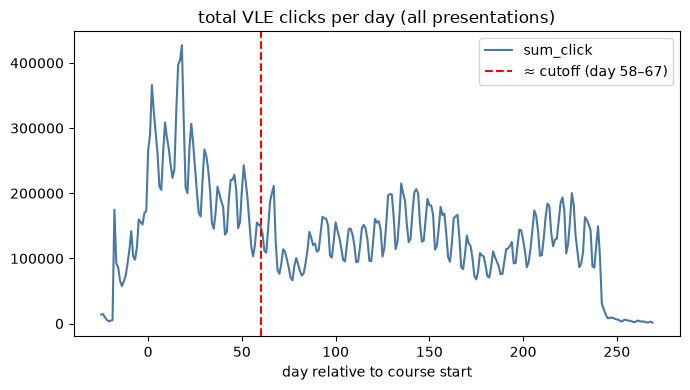

In [7]:
courses["cutoff"] = (0.25 * courses.module_presentation_length).round().astype(int)
print("cutoff day per module-presentation:")
print(courses.pivot_table(index="code_module", columns="code_presentation", values="cutoff"))

tma = assessments.merge(courses, on=["code_module", "code_presentation"])
tma = tma[tma.assessment_type == "TMA"]
early_tma = tma[tma.date <= tma.cutoff]
print("\nTMAs already due by cutoff (count per module-presentation):")
print(early_tma.groupby(["code_module", "code_presentation"]).size().unstack())

sv = student_vle.merge(courses[["code_module", "code_presentation", "cutoff"]],
                       on=["code_module", "code_presentation"])
print(f"\nshare of all VLE click-rows on/before cutoff: {(sv.date <= sv.cutoff).mean():.1%}")

early_clicks = (sv[sv.date <= sv.cutoff].groupby(KEY).sum_click.sum()
                .rename("early_clicks"))
students = student_info.merge(early_clicks, on=KEY, how="left")
students.early_clicks = students.early_clicks.fillna(0)
zero = students.early_clicks == 0
print(f"students with ZERO early-window clicks: {zero.sum():,} ({zero.mean():.1%})"
      f" - their at-risk rate: {students[zero].at_risk.mean():.1%}"
      f" vs {students[~zero].at_risk.mean():.1%} for active students")

fig, ax = plt.subplots(figsize=(7, 4))
daily = sv.groupby("date").sum_click.sum()
daily.plot(ax=ax, color="#4878a8")
ax.axvline(60, ls="--", c="r", label="≈ cutoff (day 58–67)")
ax.set_title("total VLE clicks per day (all presentations)")
ax.set_xlabel("day relative to course start")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "vle_clicks_timeline.png", dpi=120)
plt.show()

In [8]:
# Population definition: who is a valid prediction target at the cutoff?
pop = (students.merge(registration, on=KEY)
       .merge(courses[["code_module", "code_presentation", "cutoff"]],
              on=["code_module", "code_presentation"]))
already_gone = pop.date_unregistration <= pop.cutoff
print(f"students already unregistered by cutoff: {already_gone.sum():,} "
      f"({already_gone.mean():.1%}) - outcomes: "
      f"{pop[already_gone].final_result.value_counts().to_dict()}")

kept = pop[~already_gone]
print(f"\nmodeling population (still enrolled at cutoff): {len(kept):,}")
print(f"at-risk rate in modeling population: {kept.at_risk.mean():.1%}")
print("\nby presentation:")
print(kept.groupby("code_presentation").at_risk.agg(["count", "mean"]).round(3))

students already unregistered by cutoff: 6,352 (19.5%) - outcomes: {'Withdrawn': 6344, 'Fail': 8}

modeling population (still enrolled at cutoff): 26,241
at-risk rate in modeling population: 41.4%

by presentation:
                   count   mean
code_presentation              
2013B               3923  0.466
2013J               7386  0.394
2014B               6186  0.457
2014J               8746  0.376


**Conclusion (Early window):** The prediction point works. Every
module-presentation has 1–3 TMAs already due by the cutoff **except GGG-2014B (zero)** —
so early-TMA features must handle "no TMA due yet" explicitly (DQ-05). ~44% of all VLE
activity happens in the early window, and total absence of early clicks is a near-certain
risk signal (98.7% at risk) — strong evidence that early engagement features carry signal.

**Population decision (DQ-04):** students who unregistered **on or before the cutoff**
(19.5%) are excluded from the modeling population: at prediction time their outcome is
already known, so "predicting" them would be answer-key leakage and would inflate recall.
After exclusion the at-risk rate is **41.4%** — this is the class balance that matters
for modeling.

## Final summary

All audit areas are covered with written conclusions above; decisions and open items are
consolidated in [`docs/data_audit.md`](../docs/data_audit.md) (audit summary, issue log,
split decision, leakage register, preprocessing plan, gate status).